#  Инициализация весов нейронных сетей. Способы регуляризации нейронных сетей. Продвинутые алгоритмы градиентного спуска.

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Deep Learning with PyTorch (2020) Авторы: Eli Stevens, Luca Antiga, Thomas Viehmann
* https://pytorch.org/docs/stable/nn.init.html
* https://machinelearningmastery.com/dropout-for-regularizing-deep-neural-networks/
* https://machinelearningmastery.com/batch-normalization-for-training-of-deep-neural-networks/
* https://pytorch.org/docs/stable/optim.html

## Задачи для совместного разбора

1\. Инициализируйте веса полносвязного слоя единицами, а смещения - нулями.

In [ ]:
import torch.nn.init as init

layer = nn.Linear(3, 2)
init.ones_(layer.weight)
init.zeros_(layer.bias)

layer.weight, layer.bias

(Parameter containing:
 tensor([[1., 1., 1.],
         [1., 1., 1.]], requires_grad=True),
 Parameter containing:
 tensor([0., 0.], requires_grad=True))

2\. Изучите, как работает слой `nn.Dropout` в режиме обучения модели и в режиме использования модели.

In [ ]:
import torch
import torch.nn as nn

dropout = nn.Dropout(p=0.5)
x = torch.ones(1, 10)
print(x)

dropout.train()
print(dropout(x))

dropout.eval()
print(dropout(x))

tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])
tensor([[2., 2., 0., 0., 2., 2., 0., 2., 0., 2.]])
tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])


3\. Изучите, как работает слой `nn.BatchNorm1d` в режиме обучения модели и в режиме использования модели.

In [ ]:
bn = nn.BatchNorm1d(3)  # 3 фичи
x = torch.randn(2, 3)  # Батч из 2 сэмплов
print(x)

bn.train()
print(bn(x))  # Нормализация по батчу, обновление running stats

bn.eval()
print(bn(x))  # Использование running stats

tensor([[ 1.1276,  0.3613,  0.7890],
        [-1.2137, -0.1732,  0.3713]])
tensor([[ 1.0000,  0.9999,  0.9999],
        [-1.0000, -0.9999, -0.9999]], grad_fn=<NativeBatchNormBackward0>)
tensor([[ 1.0446,  0.3680,  0.7668],
        [-1.1162, -0.1910,  0.3287]], grad_fn=<NativeBatchNormBackward0>)


## Задачи для самостоятельного решения

In [ ]:
import torch.nn as nn
import matplotlib.pyplot as plt

<p class="task" id="1"></p>

1\. Расширьте класс `torch.nn.Linear`, описав класс `InitializedLinear` и добавив возможность инициализировать веса слоя при помощи функций из пакета `torch.nn.init` (инициализацию bias оставьте по умолчанию). Обратите внимание, что данные функции имеют дополнительные параметры. Данные параметры должны передаваться в момент создания объекта класса `InitializedLinear`.

Пример создания слоя:
```
InitializedLinear(n_features, n_hidden, init_f=nn.init.uniform_, init_args={"a": 0.0, "b": 1.0})
```

- [ ] Проверено на семинаре

In [ ]:
class InitializedLinear(nn.Linear):
  def __init__(self, in_features, out_features, init_f, init_args = {}, bias = True, device = None, dtype = None):
    super().__init__(in_features, out_features, bias = bias, device = device, dtype = dtype)
    init_f(self.weight, **init_args)

<p class="task" id="2"></p>

2\. Решите задачу регрессии несколько раз, изменяя способ инициализации весов. Рассмотрите следующие варианты:
* `nn.init.uniform_`
* `nn.init.normal_`
* `nn.init.constant_`
* `nn.xavier_uniform_`
* `nn.kaiming_uniform_`

Визуализируйте график изменения значений MSE с ходом эпох. Дайте кривым, соответствующие разным способам инициализации, различные цвета и добавьте подписи. Для улучшения читаемости графиков можно рассматривать области экстремальных значений отдельно.

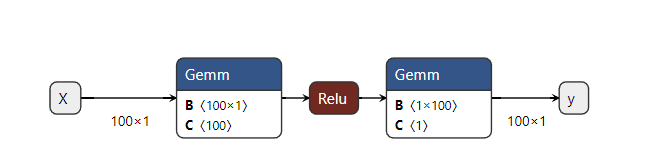

- [ ] Проверено на семинаре

In [ ]:
import torch as th
X = th.linspace(0, 1, 100).view(-1, 1)
y = th.sin(2 * th.pi * X) + 0.1 * th.rand(X.size())

In [ ]:
class SimpleNN(nn.Module):
  def __init__(self, init_f, init_args):
    super().__init__()
    self.layer1 = InitializedLinear(1, 100, init_f, init_args)
    self.layer2 = InitializedLinear(100, 1, init_f, init_args)
    self.relu = nn.ReLU()

  def forward(self, x):
    h1 = self.layer1(x)
    h2 = self.relu(h1)
    y_pred = self.layer2(h2)
    return y_pred

In [ ]:
def train_model(model, X, y, epochs = 100, lr = 0.01):
  criterion = nn.MSELoss()
  optimizer = th.optim.SGD(model.parameters(), lr = lr)
  losses = []

  for epoch in range(epochs):
    optimizer.zero_grad()
    y_pred = model(X)
    loss = criterion(y_pred, y)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

  return losses

In [ ]:
init_methods = [(nn.init.uniform_, {"a": -0.1, "b": 0.1}),
    (nn.init.normal_, {"mean": 0.0, "std": 0.1}),
    (nn.init.constant_, {"val": 0.1}),
    (nn.init.xavier_uniform_, {}),
    (nn.init.kaiming_uniform_, {})]

In [ ]:
results = {}

for init_f, init_args in init_methods:
  model = SimpleNN(init_f, init_args)
  losses = train_model(model, X, y)
  results[init_f.__name__] = losses

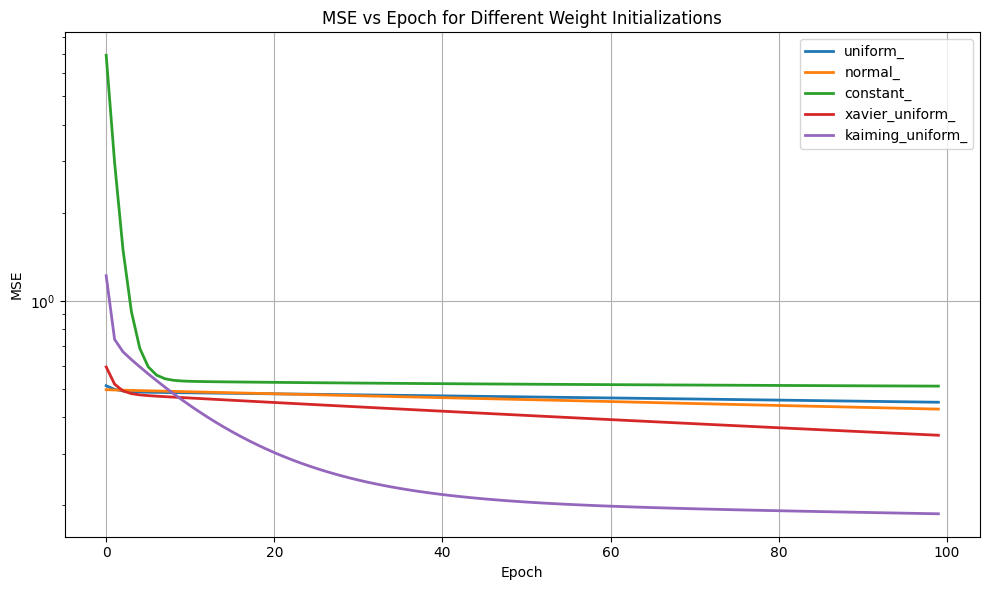

In [ ]:
plt.figure(figsize=(10, 6))

for method, losses in results.items():
    plt.plot(range(100), losses, label=method, linewidth=2)

plt.title('MSE vs Epoch for Different Weight Initializations')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.yscale('log')
plt.tight_layout()

plt.show()

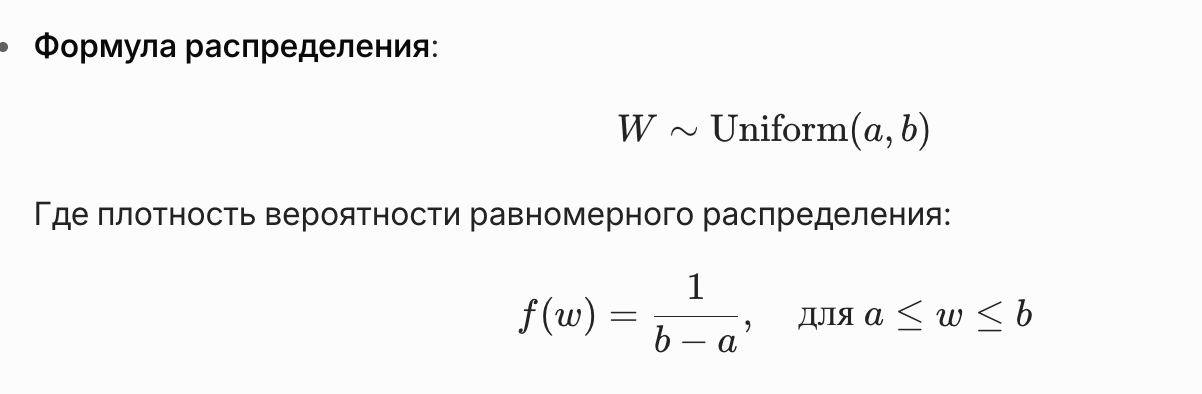

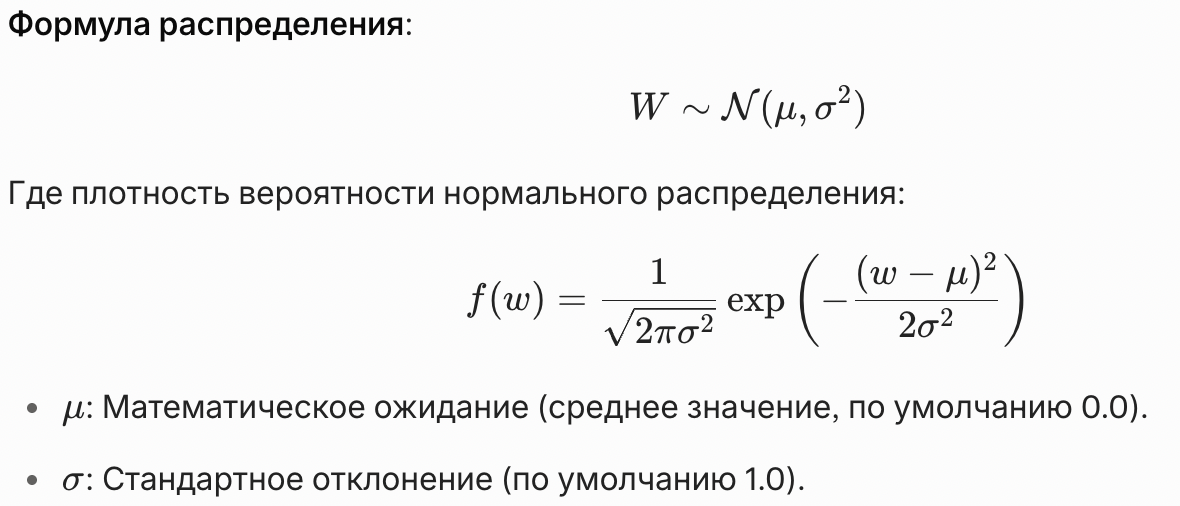

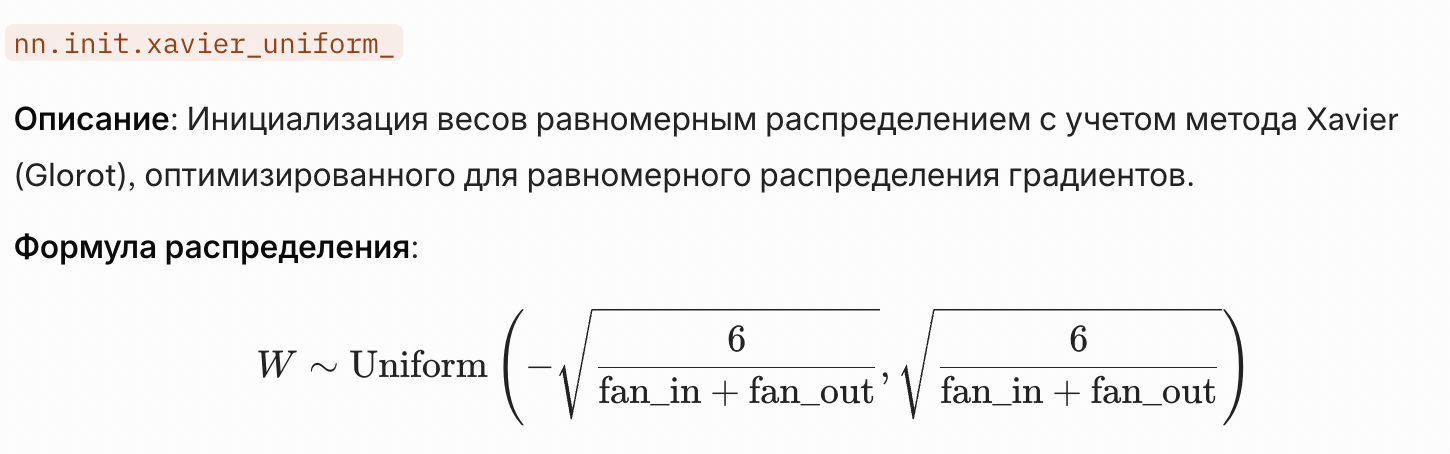

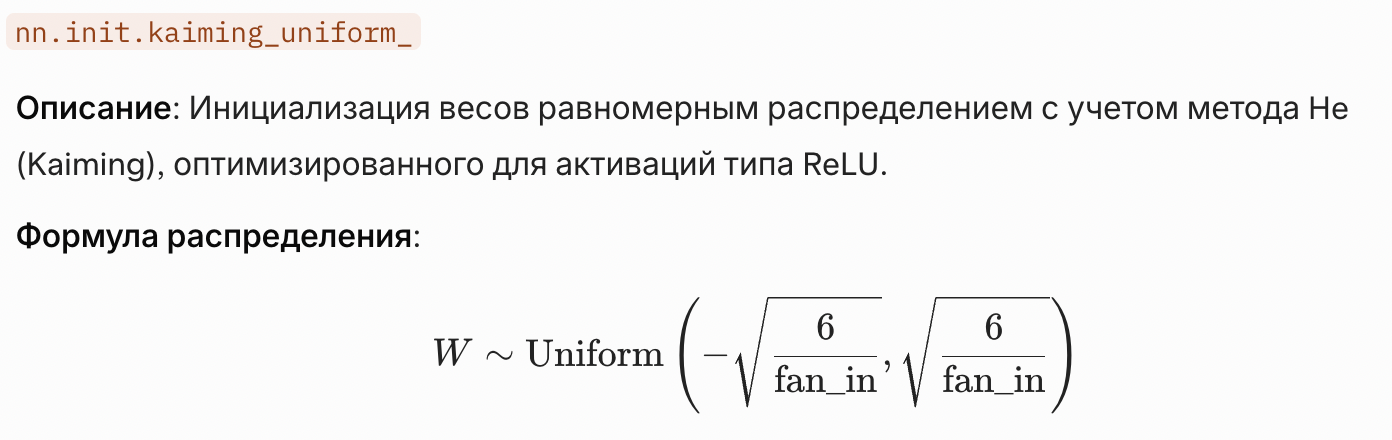

<p class="task" id="3"></p>

3\. Исследуйте, как добавление дропаута влияет на процесс обучения модели. Решите задачу регрессии несколько раз, изменяя значения вероятности дропаута $p$ от 0 до 0.8. В качестве модели рассмотрите нейронную сеть с одним скрытым слоем.

Визуализируйте график изменения значений $R^2$ в зависимости от вероятности дропаута $p$ на обучающей и тестовой выборке. Визуализируйте на отдельном графике зависимости разности между $R^2$ на обучающей выборки и $R^2$ на тестовой выборке.

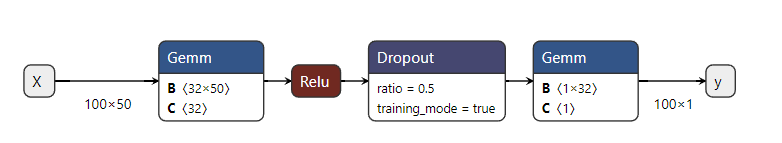

- [ ] Проверено на семинаре

In [ ]:
from sklearn.datasets import make_regression
import torch as th
from sklearn.model_selection import train_test_split

th.manual_seed(42)
X, y, coef = make_regression(
    n_samples=100,
    n_features=50,
    n_informative=20,
    noise=2,
    coef=True,
    random_state=42,

)
X = th.FloatTensor(X)
y = th.FloatTensor(y).reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [ ]:
class RegressionNN(nn.Module):
  def __init__(self, dropout_rate):
    super().__init__()
    self.layer1 = nn.Linear(50, 32)
    self.relu = nn.ReLU()
    self.dropout = nn.Dropout(dropout_rate)
    self.layer2 = nn.Linear(32, 1)

  def forward(self, x):
    h1 = self.layer1(x)
    h2 = self.relu(h1)
    h3 = self.dropout(h2)
    y_pred = self.layer2(h3)
    return y_pred

In [ ]:
def train_model(model, X_train, y_train, X_test, y_test, epochs = 2000, lr = 0.01):
  criterion = nn.MSELoss()
  optimizer = th.optim.Adam(model.parameters(), lr=lr)
  train_losses = []
  test_losses = []

  for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    model.eval()
    with th.no_grad():
      test_y_pred = model(X_test)
      test_loss = criterion(test_y_pred, y_test)
      test_losses.append(test_loss.item())

  return train_losses, test_losses

In [ ]:
def r2_score(y_true, y_pred):
  ss_res = th.sum((y_true - y_pred)**2)
  ss_tot = th.sum((y_true - th.mean(y_true))**2)
  r2 = 1 - ss_res/ss_tot
  return r2.item()

In [ ]:
import numpy as np

dropout_rates = np.arange(0, 0.9, 0.1)
train_r2_scores = []
test_r2_scores = []

for p in dropout_rates:
  model = RegressionNN(p)
  train_losses, test_losses = train_model(model, X_train, y_train, X_test, y_test)

  with th.no_grad():
    model.eval()
    train_pred = model(X_train)
    test_pred = model(X_test)
    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

  train_r2_scores.append(train_r2)
  test_r2_scores.append(test_r2)

r2_diff = np.array(train_r2_scores) - np.array(test_r2_scores)

In [ ]:
print("r2_diff:", r2_diff)
print("train_r2_scores:", train_r2_scores)
print("test_r2_scores:", test_r2_scores)

r2_diff: [0.48297042 0.37464708 0.28439933 0.23902726 0.25552034 0.24137998
 0.23799658 0.24567318 0.25467169]
train_r2_scores: [1.0, 0.9972707629203796, 0.9989210367202759, 0.9982138872146606, 0.9962607026100159, 0.9934147596359253, 0.9861449003219604, 0.9824838638305664, 0.9471914768218994]
test_r2_scores: [0.5170295834541321, 0.6226236820220947, 0.7145217061042786, 0.7591866254806519, 0.7407403588294983, 0.7520347833633423, 0.7481483221054077, 0.7368106842041016, 0.6925197839736938]


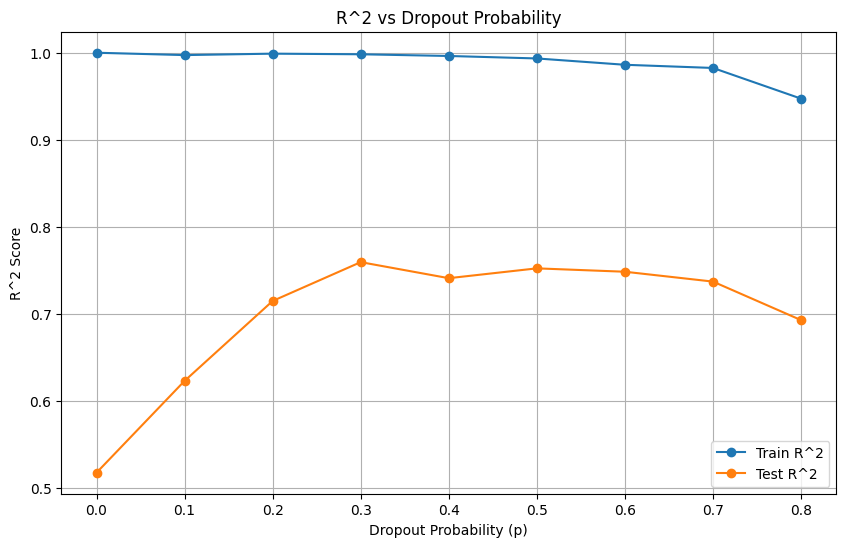

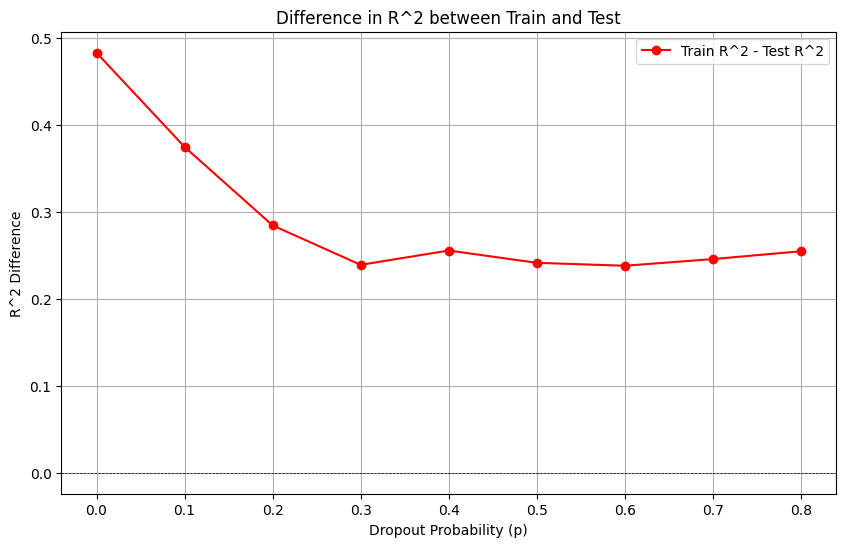

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(dropout_rates, train_r2_scores, label='Train R^2', marker='o')
plt.plot(dropout_rates, test_r2_scores, label='Test R^2', marker='o')
plt.xlabel('Dropout Probability (p)')
plt.ylabel('R^2 Score')
plt.title('R^2 vs Dropout Probability')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(dropout_rates, r2_diff, label='Train R^2 - Test R^2', color='red', marker='o')
plt.xlabel('Dropout Probability (p)')
plt.ylabel('R^2 Difference')
plt.title('Difference in R^2 between Train and Test')
plt.legend()
plt.grid(True)
plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
plt.show()

<p class="task" id="4"></p>

4\. Решите задачу регрессии с- и без использования пакетной нормализации. Покажите, как меняется результат обучения моделей при различных значениях скорости обучения (0.001, 0.01, 0.1) за одно и то же количество эпох.

Визуализируйте график изменения значений $R^2$ в зависимости от эпохи при различных значениях скорости обучения с- и без использования пакетной нормализации.

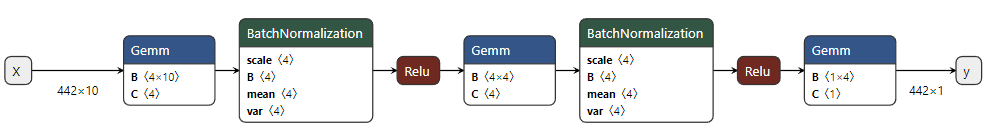

- [ ] Проверено на семинаре

In [ ]:
from sklearn.datasets import load_diabetes
from sklearn.datasets import make_regression
import torch as th
from sklearn.model_selection import train_test_split

X, y = load_diabetes(return_X_y=True)
X = th.FloatTensor(X)
y = th.FloatTensor(y).reshape(-1, 1)
y = (y - y.mean())/y.std()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
class RegressionNNNoBN(nn.Module):
    def __init__(self, input_size=10):
        super().__init__()
        self.layer1 = nn.Linear(input_size, 4)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(4, 4)
        self.layer3 = nn.Linear(4, 1)

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        x = self.relu(x)
        x = self.layer3(x)
        return x

In [ ]:
class RegressionNNWithBN(nn.Module):
    def __init__(self, input_size=10):
        super().__init__()
        self.layer1 = nn.Linear(input_size, 4)
        self.bn1 = nn.BatchNorm1d(4)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(4, 4)
        self.bn2 = nn.BatchNorm1d(4)
        self.layer3 = nn.Linear(4, 1)

    def forward(self, x):
        x = self.layer1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.layer2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.layer3(x)
        return x

In [ ]:
def train_model(model, X_train, y_train, X_test, y_test, lr=0.01, epochs=100):
    criterion = nn.MSELoss()
    optimizer = th.optim.Adam(model.parameters(), lr=lr)
    train_r2_scores = []
    test_r2_scores = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)
        loss.backward()
        optimizer.step()

        model.eval()
        with th.no_grad():
            train_pred = model(X_train)
            test_pred = model(X_test)
            train_r2 = r2_score(y_train, train_pred)
            test_r2 = r2_score(y_test, test_pred)
            train_r2_scores.append(train_r2)
            test_r2_scores.append(test_r2)

    return train_r2_scores, test_r2_scores

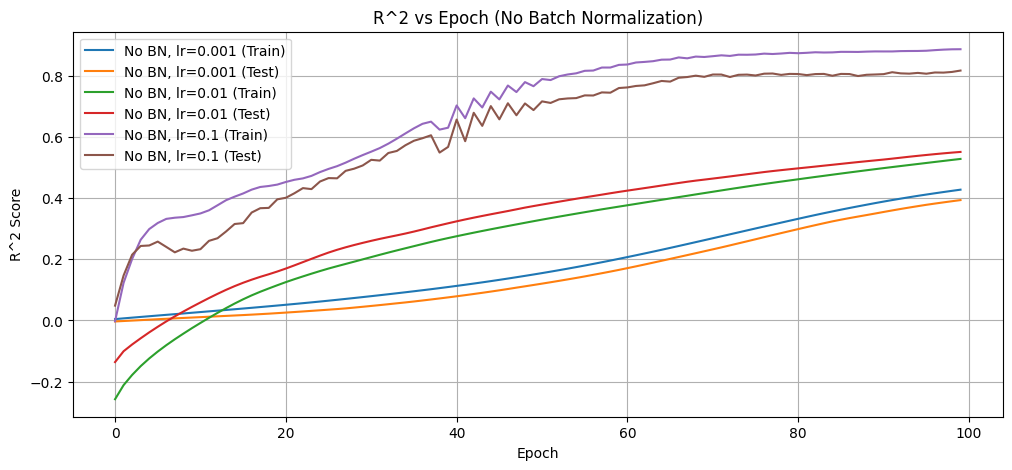

In [ ]:
learning_rates = [0.001, 0.01, 0.1]
epochs = 100

plt.figure(figsize=(12, 5))
for lr in learning_rates:
    model = RegressionNNNoBN(input_size=X.shape[1])
    train_r2, test_r2 = train_model(model, X_train, y_train, X_test, y_test, lr=lr, epochs=epochs)
    plt.plot(range(epochs), train_r2, label=f'No BN, lr={lr} (Train)')
    plt.plot(range(epochs), test_r2, label=f'No BN, lr={lr} (Test)')

plt.title('R^2 vs Epoch (No Batch Normalization)')
plt.xlabel('Epoch')
plt.ylabel('R^2 Score')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
train_r2, test_r2

([-0.002637624740600586,
  0.12297564744949341,
  0.20096206665039062,
  0.26372379064559937,
  0.29866814613342285,
  0.31857043504714966,
  0.3320469856262207,
  0.3358333110809326,
  0.33798813819885254,
  0.3436552882194519,
  0.3498252034187317,
  0.36006593704223633,
  0.37649261951446533,
  0.393080472946167,
  0.4046141505241394,
  0.41513752937316895,
  0.4276502728462219,
  0.43631237745285034,
  0.43952178955078125,
  0.4441153407096863,
  0.45267778635025024,
  0.45981043577194214,
  0.46439868211746216,
  0.47258371114730835,
  0.4849931001663208,
  0.4953725337982178,
  0.5043681859970093,
  0.5158473253250122,
  0.528660774230957,
  0.5405604243278503,
  0.551784873008728,
  0.5635327696800232,
  0.5779447555541992,
  0.5942287445068359,
  0.6113604307174683,
  0.6281569004058838,
  0.6428196430206299,
  0.6499062776565552,
  0.6238287687301636,
  0.6301150918006897,
  0.7027850151062012,
  0.6610875129699707,
  0.7259131669998169,
  0.696292519569397,
  0.74792420864105

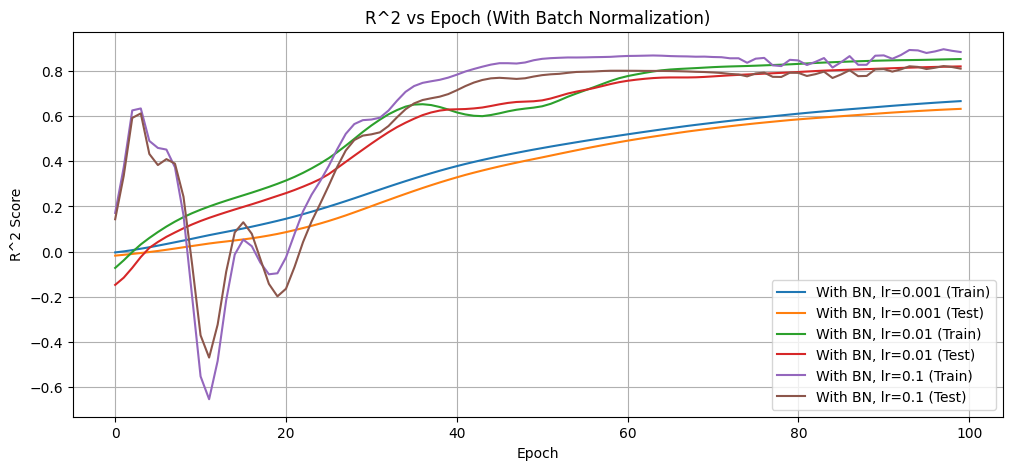

In [ ]:
plt.figure(figsize=(12, 5))
for lr in learning_rates:
    model = RegressionNNWithBN(input_size=X.shape[1])
    train_r2, test_r2 = train_model(model, X_train, y_train, X_test, y_test, lr=lr, epochs=epochs)
    plt.plot(range(epochs), train_r2, label=f'With BN, lr={lr} (Train)')
    plt.plot(range(epochs), test_r2, label=f'With BN, lr={lr} (Test)')

plt.title('R^2 vs Epoch (With Batch Normalization)')
plt.xlabel('Epoch')
plt.ylabel('R^2 Score')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
train_r2, test_r2

([0.171167254447937,
  0.37326544523239136,
  0.6259512305259705,
  0.6345798373222351,
  0.49056094884872437,
  0.459553599357605,
  0.45227301120758057,
  0.3738570213317871,
  0.16090041399002075,
  -0.1963977813720703,
  -0.5534946918487549,
  -0.6548547744750977,
  -0.4849439859390259,
  -0.21531999111175537,
  -0.013106703758239746,
  0.052841007709503174,
  0.023678481578826904,
  -0.04923057556152344,
  -0.10082352161407471,
  -0.09636569023132324,
  -0.026166439056396484,
  0.07804107666015625,
  0.17842978239059448,
  0.252150297164917,
  0.31203693151474,
  0.378828763961792,
  0.4538823962211609,
  0.521944522857666,
  0.5653612017631531,
  0.5827094316482544,
  0.5854281783103943,
  0.593600869178772,
  0.6250317096710205,
  0.6688132286071777,
  0.7082784175872803,
  0.7338953018188477,
  0.7480552196502686,
  0.7551723122596741,
  0.7616009712219238,
  0.7713382244110107,
  0.7842717170715332,
  0.7984078526496887,
  0.8096326589584351,
  0.8198438286781311,
  0.82906162

<p class="task" id="5"></p>

5\. Решите задачу регрессии c использованием различных алгоритмов градиентного спуска. Покажите, как меняется результат обучения моделей при использовании различных алгоритмов (Adam, Adagram, RMSProp, SGD) за одно и то же количество эпох с одной и той же скоростью обучения. Используйте модель с архитектурой, аналогичной модели из предыдущей задачи.

Визуализируйте график изменения значений MAPE в зависимости от эпохи при использовании различных алгоритмов градиентного спуска.

- [ ] Проверено на семинаре

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error as mape

In [ ]:
def load_boston():
    import pandas as pd
    import numpy as np

    data_url = "http://lib.stat.cmu.edu/datasets/boston"
    raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
    data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
    target = raw_df.values[1::2, 2]
    return data, target

<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-3520487584.py:6: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


In [ ]:
X, y = load_boston()
X = th.FloatTensor(X)
y = th.FloatTensor(y).reshape(-1, 1)

In [ ]:
X = (X - X.mean(dim=0)) / X.std(dim=0)
y = (y - y.mean()) / y.std()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X.shape[1]

13

In [ ]:
def train_model(model, X_train, y_train, X_test, y_test, optimizer, epochs=100, lr=0.01):
    criterion = nn.MSELoss()
    optimizer = optimizer(model.parameters(), lr=lr)
    train_mape_scores = []
    test_mape_scores = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)
        loss.backward()
        optimizer.step()

        model.eval()
        with th.no_grad():
            train_pred = model(X_train)
            test_pred = model(X_test)
            train_mape = mape(y_train.numpy(), train_pred.numpy()) * 100
            test_mape = mape(y_test.numpy(), test_pred.numpy()) * 100
            train_mape_scores.append(train_mape)
            test_mape_scores.append(test_mape)

        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, Train MAPE: {train_mape:.2f}%, Test MAPE: {test_mape:.2f}%')

    return train_mape_scores, test_mape_scores

In [ ]:
epochs = 100
learning_rate = 0.01
optimizers = {
    'Adam': th.optim.Adam,
    'Adagrad': th.optim.Adagrad,
    'RMSProp': th.optim.RMSprop,
    'SGD': th.optim.SGD
}

Epoch [10/100], Loss: 0.8264, Train MAPE: 248.45%, Test MAPE: 304.90%
Epoch [20/100], Loss: 0.4871, Train MAPE: 157.28%, Test MAPE: 220.96%
Epoch [30/100], Loss: 0.3529, Train MAPE: 208.07%, Test MAPE: 201.85%
Epoch [40/100], Loss: 0.3179, Train MAPE: 211.97%, Test MAPE: 132.19%
Epoch [50/100], Loss: 0.2919, Train MAPE: 186.95%, Test MAPE: 143.75%
Epoch [60/100], Loss: 0.2700, Train MAPE: 173.47%, Test MAPE: 156.82%
Epoch [70/100], Loss: 0.2541, Train MAPE: 168.83%, Test MAPE: 119.75%
Epoch [80/100], Loss: 0.2388, Train MAPE: 170.95%, Test MAPE: 116.38%
Epoch [90/100], Loss: 0.2186, Train MAPE: 170.89%, Test MAPE: 94.98%
Epoch [100/100], Loss: 0.1939, Train MAPE: 185.78%, Test MAPE: 139.21%
Epoch [10/100], Loss: 1.0905, Train MAPE: 385.30%, Test MAPE: 459.20%
Epoch [20/100], Loss: 0.9424, Train MAPE: 340.00%, Test MAPE: 437.08%
Epoch [30/100], Loss: 0.8125, Train MAPE: 289.10%, Test MAPE: 412.32%
Epoch [40/100], Loss: 0.6915, Train MAPE: 257.59%, Test MAPE: 366.77%
Epoch [50/100], Loss

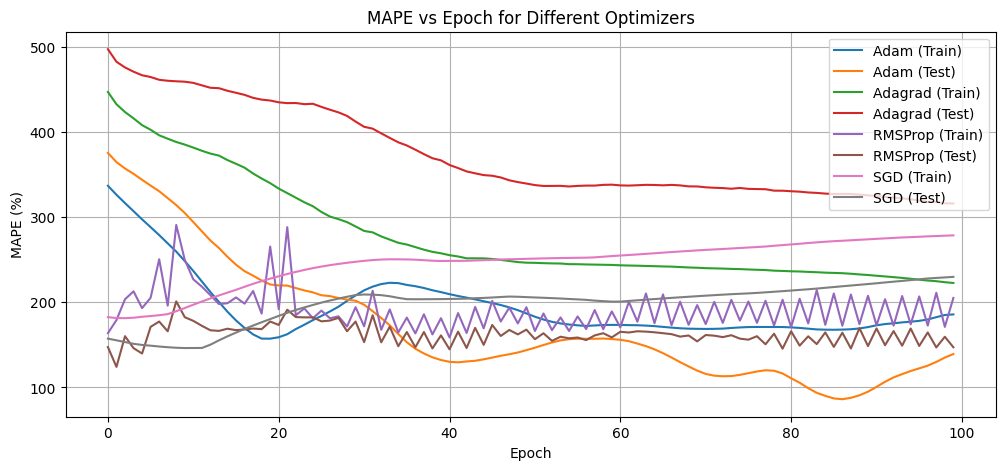

In [ ]:
plt.figure(figsize=(12, 5))
for name, optim in optimizers.items():
    model = RegressionNNWithBN(input_size=X.shape[1])
    train_mape, test_mape = train_model(model, X_train, y_train, X_test, y_test, optim, epochs=epochs, lr=learning_rate)
    plt.plot(range(epochs), train_mape, label=f'{name} (Train)')
    plt.plot(range(epochs), test_mape, label=f'{name} (Test)')

plt.title('MAPE vs Epoch for Different Optimizers')
plt.xlabel('Epoch')
plt.ylabel('MAPE (%)')
plt.legend()
plt.grid(True)
plt.show()

<p class="task" id="6"></p>

6\. Решите задачу регрессии c использованием ранней остановки. Разбейте набор данных на обучающую и валидационную выборку в соотношении 80 на 20. Остановите процесс обучения, если целевая метрика (MAPE) не уменьшалась в течении последних $k$ ($k$ - гиперпараметр метода) эпох. В момент остановки выведите сообщение с текущим номером эпохи.

- [ ] Проверено на семинаре

In [ ]:
X, y = load_boston()
X = th.FloatTensor(X)
y = th.FloatTensor(y).reshape(-1, 1)
X = (X - X.mean(dim=0)) / X.std(dim=0)
y = (y - y.mean()) / y.std()
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
def train_with_early_stopping(model, X_train, y_train, X_val, y_val, epochs=1000, lr=0.001, patience=10):
    criterion = nn.MSELoss()
    optimizer = th.optim.Adam(model.parameters(), lr=lr)
    best_val_mape = float('inf')
    patience_counter = 0
    val_mape_scores = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)
        loss.backward()
        optimizer.step()

        model.eval()
        with th.no_grad():
            val_pred = model(X_val)
            val_mape = mape(y_val.numpy(), val_pred.numpy()) * 100
            val_mape_scores.append(val_mape)

        if val_mape < best_val_mape:
            best_val_mape = val_mape
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch + 1} with best validation MAPE: {best_val_mape:.2f}%")
            break

        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, Validation MAPE: {val_mape:.2f}%')

    return val_mape_scores, epoch + 1

In [ ]:
model = RegressionNNWithBN(input_size=X.shape[1])
val_mape_scores, final_epoch = train_with_early_stopping(model, X_train, y_train, X_val, y_val, epochs=1000, lr=0.01, patience=30)

Epoch [10/1000], Loss: 0.8405, Validation MAPE: 144.16%
Epoch [20/1000], Loss: 0.5059, Validation MAPE: 236.86%
Epoch [30/1000], Loss: 0.2576, Validation MAPE: 220.80%
Early stopping triggered at epoch 37 with best validation MAPE: 95.04%


## Обратная связь
- [ ] Хочу получить обратную связь по решению